In [1]:
import numpy as np
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


#### Helper Functions

In [2]:
#Hill Function Definitions
def hill_activate(K, n, P):
    P = np.maximum(P, 1e-12)
    K = np.maximum(K, 1e-12)
    n = np.maximum(n, 1e-12)

    Pn = np.exp(n * np.log(P))
    Kn = np.exp(n * np.log(K))

    return Pn / (Kn + Pn)

def hill_repress(K, n, P):
    P = np.maximum(P, 1e-12)
    K = np.maximum(K, 1e-12)
    n = np.maximum(n, 1e-12)

    Pn = np.exp(n * np.log(P))
    Kn = np.exp(n * np.log(K))

    return Kn / (Kn + Pn)

def hill_biphasic(K1, K2, n1, n2, P):
    return hill_activate(K1, n1, P) * hill_repress(K2, n2, P)

def dhill_biphasic(K1, K2, n1, n2, P):
    Kn1, Kn2, = K1**n1, K2**n2
    numerator = Kn2 * P**(n1 - 1) * (n1*Kn2*Kn1 - P**n2*(Kn1*(n2 - n1) + n2*P**n1))
    denominator = (Kn2 + P**n2)**2 * (Kn1 + P**n1)**2
    return numerator / denominator 

In [3]:
def create_parameter_dictionary():
    dictionary = {
        'synthesis': 
        {
            'GnRH': 2.44,
            'LH': 6.35,
            'Estrogen': 2.45
        },
        'clearance': 
        {
            'GnRH': 0.17,
            'LH': 0.35,
            'Estrogen': 0.09
        },
        'regulatory': 
        {
            ('Estrogen', 'GnRH'): 
            {
                'n': (10.00, 4.41),
                'K': (0.16, 0.56)
            },
            ('GnRH', 'LH'): 
            {
                'n': (5.73, 9),
                'K': (6.62, 11)
            },
            ('LH', 'Estrogen'): 
            {
                'n': (6.76, 10.00),
                'K': (9.75, 20.25)
            }
        },
        'control': 
        {
            'GnRH': 1,
            'LH': 1,
            'Estrogen': 1
        },
        'clamping':
        {
            'clamp_min': 1e-8,
            'clamp_max': 100
        }
    }
    return dictionary

#### LQR Solver

In [4]:
def AQR_Solver(tv, X0, A, B, Q, R, P, c, s, n):
    '''
    Parameters:
    ----------
    tv : tuple containing start and stop times (t0,tf) that can be passed into solve_ivp
    X0 : Initial conditions on state variables
    A, Q: ndarrays of shape (d,d)
    B : ndarray of shape (d,d)
    R : ndarray of shape (d,d)
    P : ndarray of shape (d,d)
    Returns
    -------
    Z : ndarray of shape (n+1,d), the state vector at each time
    U : ndarray of shape (n+1,), the control values
    '''
    def ODE(t, z):
        return (A - B @ np.linalg.inv(R) @ B.T @ P) @ z + (c - B @ np.linalg.inv(R) @ B.T @ s)
    
    Z = solve_ivp(ODE, t_span=tv, y0=X0, t_eval=np.linspace(tv[0], tv[1], n), method='Radau').y
    U = Z.T @ (-np.linalg.inv(R) @ B.T @ P).T + s.T @ (-np.linalg.inv(R) @ B.T)
    return Z.T, np.squeeze(U.T)

#### Nonlinear Model

In [5]:
def nonlinear_menstrual_ode(t, y, u, param_dict):
    GnRH, LH, Estrogen = y[0], y[1], y[2]
    
    #clamping the hormones to avoid numerical instability and physical feasability
    clamp_min = param_dict['clamping']['clamp_min']
    clamp_max = param_dict['clamping']['clamp_max']
    GnRH = max(GnRH, clamp_min)
    LH = max(LH, clamp_min)
    Estrogen = max(Estrogen, clamp_min)
    uG, uL, uE = np.clip(u(t), clamp_min, clamp_max)

    # ---------------- GnRH ----------------
    synth_E_on_GnRH = param_dict['synthesis']['GnRH']
    clearance_GnRH = param_dict['clearance']['GnRH']
    n_EGnRH1, n_EGnRH2 = param_dict['regulatory'][('Estrogen', 'GnRH')]['n']
    K_EGnRH1, K_EGnRH2 = param_dict['regulatory'][('Estrogen', 'GnRH')]['K']
    alphaG = param_dict['control']['GnRH']
    dGnRH = (synth_E_on_GnRH * (hill_biphasic(K_EGnRH1, K_EGnRH2, n_EGnRH1, n_EGnRH2, Estrogen)) 
             - clearance_GnRH * GnRH 
             + alphaG * uG)
    
    # ---------------- LH ----------------
    synth_LH_GnRH = param_dict['synthesis']['LH']
    clearance_LH = param_dict['clearance']['LH']
    n1_GLH, n2_GLH = param_dict['regulatory'][('GnRH', 'LH')]['n']
    K1_GLH, K2_GLH = param_dict['regulatory'][('GnRH', 'LH')]['K']
    alphaL = param_dict['control']['LH']
    dLH = (synth_LH_GnRH * hill_biphasic(K1_GLH, K2_GLH, n1_GLH, n2_GLH, GnRH)
           - clearance_LH * LH
           + alphaL * uL)
    
    # ---------------- Estrogen ----------------
    synth_Estrogen = param_dict['synthesis']['Estrogen']
    clearance_Estrogen = param_dict['clearance']['Estrogen']
    n1_L_E, n2_L_E = param_dict['regulatory'][('LH', 'Estrogen')]['n']
    K1_L_E, K2_L_E = param_dict['regulatory'][('LH', 'Estrogen')]['K']
    alphaE = param_dict['control']['Estrogen']
    dEstrogen = (synth_Estrogen * (hill_biphasic(K1_L_E, K2_L_E, n1_L_E, n2_L_E, LH))
                 - clearance_Estrogen * Estrogen
                 + alphaE * uE)
    return np.array([dGnRH, dLH, dEstrogen])
    

#### Linearization

In [6]:
def linearized_init(X0, param_dict):

    GnRH, LH, Estrogen = X0
    #compute the jacobian of our nonlinear dynamics at this point
    clearance_GnRH = param_dict['clearance']['GnRH']
    synth_GnRH = param_dict['synthesis']['GnRH']
    n_EGnRH1, n_EGnRH2 = param_dict['regulatory'][('Estrogen', 'GnRH')]['n']
    K_EGnRH1, K_EGnRH2 = param_dict['regulatory'][('Estrogen', 'GnRH')]['K']

    synth_LH = param_dict['synthesis']['LH']
    clearance_LH = param_dict['clearance']['LH']
    n1_GLH, n2_GLH = param_dict['regulatory'][('GnRH', 'LH')]['n']
    K1_GLH, K2_GLH = param_dict['regulatory'][('GnRH', 'LH')]['K']

    synth_Estrogen = param_dict['synthesis']['Estrogen']
    clearance_Estrogen = param_dict['clearance']['Estrogen']
    n1_L_E, n2_L_E = param_dict['regulatory'][('LH', 'Estrogen')]['n']
    K1_L_E, K2_L_E = param_dict['regulatory'][('LH', 'Estrogen')]['K']


    A = np.array([
        [-clearance_GnRH, 0, synth_GnRH * dhill_biphasic(K_EGnRH1, K_EGnRH2, n_EGnRH1, n_EGnRH2, Estrogen)],
        [synth_LH * dhill_biphasic(K1_GLH, K2_GLH, n1_GLH, n2_GLH, GnRH), -clearance_LH, 0],
        [0, synth_Estrogen * dhill_biphasic(K1_L_E, K2_L_E, n1_L_E, n2_L_E, LH), -clearance_Estrogen]
    ])

    #calculate the B matrix
    alphaG = param_dict['control']['GnRH']
    alphaL = param_dict['control']['LH']
    alphaE = param_dict['control']['Estrogen']

    B = np.diag([alphaG, alphaL, alphaE])

    #calculate the Q and R matrices from the control
    control_penalty_weight = 10
    dim_state = np.shape(X0)[0]
    Q = np.eye(dim_state)
    R = control_penalty_weight * np.eye(dim_state)

    return A, B, Q, R

#### Solving

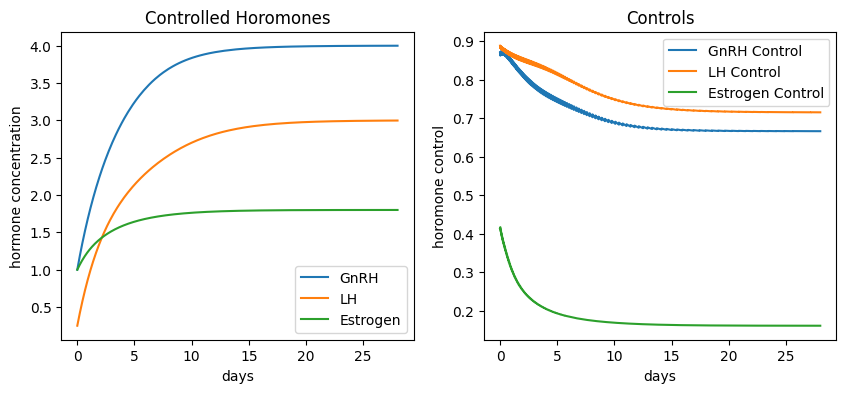

In [7]:
#Hyperparameters
num_cycles = 1
num_intervals = 119
Tf = 28 * num_cycles
samples_per_interval = 10
state_dimension = 3
param_dictionary = create_parameter_dictionary()
alphaG = param_dictionary['control']['GnRH']
alphaL = param_dictionary['control']['LH']
alphaE = param_dictionary['control']['Estrogen']
B = np.diag([alphaG, alphaL, alphaE])

clamp_min = param_dictionary['clamping']['clamp_min']
clamp_max = param_dictionary['clamping']['clamp_max']

#constructing arrays for storing the results
time_domain = (0, Tf)
subinterval_points = np.geomspace(1, Tf + 1, num_intervals + 1) - 1
optimal_x = np.empty((num_intervals * samples_per_interval, state_dimension))
optimal_u = np.empty((num_intervals * samples_per_interval, state_dimension))
full_domain = np.empty(num_intervals * samples_per_interval)

#initial X0, we will change this as we go along so we start at where our ODE left off
initial_conditions = {'GnRH': 1.0, 'LH': 0.25, 'Estrogen': 1.0}
X0 = np.array([initial_conditions['GnRH'], initial_conditions['LH'], initial_conditions['Estrogen']])
target_x = lambda t: np.array([4, 3, 1.8])
target_x_dot = lambda t: np.array([0, 0, 0])

#calculating of u_nominal
grid = np.linspace(0, Tf, 2000)
target_x_samples = np.vstack([target_x(grid_point) for grid_point in grid])
target_derivative_samples = np.vstack([target_x_dot(grid_point) for grid_point in grid])
f_target = np.array([
    nonlinear_menstrual_ode(t, x, lambda t: np.zeros(state_dimension), param_dictionary) 
    for t, x in zip(grid, target_x_samples)
])
u_nominal_samples = (target_derivative_samples - f_target) @ np.linalg.pinv(B).T
u_nominal = CubicSpline(grid, u_nominal_samples)

#for each sub interval (run LQR solver for linearized menstrual model)
for i in range(num_intervals):
    #get start and end of the interval and create the domain we will solve the ODE on
    t0, tf = subinterval_points[i], subinterval_points[i + 1]
    small_domain = np.linspace(t0, tf, samples_per_interval)

    #solve the linearized ODE (around current state) on this time interval for the control
    A, B, Q, R = linearized_init(X0, param_dictionary)
    c = (nonlinear_menstrual_ode(t0, X0, lambda t: np.zeros(state_dimension), param_dictionary) - 
        nonlinear_menstrual_ode(t0, target_x(t0), lambda t: np.zeros(state_dimension), param_dictionary))
    P = solve_continuous_are(A, B, Q, R)
    s = np.linalg.inv(-A.T + P @ B @ np.linalg.inv(R) @ B.T) @ P @ c

    _, V = AQR_Solver((t0, tf), X0 - target_x(t0), A, B, Q, R, P, c, s, samples_per_interval)
    U = V + u_nominal(small_domain).T
    u_spline = CubicSpline(small_domain, U.T)

    #apply the resulting control
    X = solve_ivp(nonlinear_menstrual_ode, t_span=(t0, tf), y0=X0, t_eval=small_domain, args=(u_spline, param_dictionary), method='Radau').y.T

    #store the results and update intiial condition
    optimal_x[i * samples_per_interval:(i + 1) * samples_per_interval, :] = X
    optimal_u[i * samples_per_interval:(i + 1) * samples_per_interval] = np.clip(U.T, clamp_min, clamp_max)
    full_domain[i * samples_per_interval:(i + 1) * samples_per_interval] = small_domain
    X0 = X[-1, :]

#plot the results of this LQR solver
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.ravel()

axes[0].plot(full_domain, optimal_x[:, 0], label='GnRH')
axes[0].plot(full_domain, optimal_x[:, 1], label='LH')
axes[0].plot(full_domain, optimal_x[:, 2], label='Estrogen')
axes[0].set(xlabel='days', ylabel='hormone concentration', title='Controlled Horomones')
axes[0].legend()

axes[1].plot(full_domain, optimal_u[:, 0], label='GnRH Control')
axes[1].plot(full_domain, optimal_u[:, 1], label='LH Control')
axes[1].plot(full_domain, optimal_u[:, 2], label='Estrogen Control')
axes[1].set(xlabel='days', ylabel='horomone control', title='Controls')
axes[1].legend()
plt.show()